# Dark-count continuous traces

Analysis for `*_1s-*.h5`, which are one-second continuous traces. The workflow below reads each file as one long waveform, removes a robust per-file baseline, finds negative-going pulses, estimates the dark-count rate, summarizes pulse properties, and shows candidate unusual events.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pmt_analysis import read_keysight_h5_direct, standard_units
from pmt_dark_counts_analysis import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Files and settings

In [2]:
DATA_DIR = Path("data/calibLED/260611/vsTime")
DATA_GLOB = "southCovered_1s_0min-*.h5" 
FILES = sorted(DATA_DIR.glob(DATA_GLOB))

if not FILES:
    raise FileNotFoundError(f"No files matching {DATA_DIR / DATA_GLOB}")

for file in FILES:
    print(file)
print(f"Number of files: {len(FILES)}")

# Pulse-finding settings. Negative PMT pulses are analyzed as positive signal = -(V - baseline).
config_dict = {
    "event_threshold_mV": 1.0, # play with it
    "min_event_separation_ns": 1_000.0,
    "pre_event_ns": 1_000.0,
    "post_event_ns": 3_000.0,
    "charge_pre_ns": 500.0,
    "charge_post_ns": 2_000.0,
    "rise_low_fracion": 0.1,
    "rise_high_fracion": 0.9
}




data/calibLED/260611/vsTime/southCovered_1s_0min-1.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-10.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-2.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-3.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-4.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-5.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-6.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-7.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-8.h5
data/calibLED/260611/vsTime/southCovered_1s_0min-9.h5
Number of files: 10


## Reader check

These files are not segmented triggered waveforms. Each file contains one long `Channel 1Data` trace with 10 million samples, covering about 1 second at 100 ns/sample.


In [3]:
time_s, voltage_trace_V, metadata = read_keysight_h5_direct(FILES[0])
time_ns, voltage_trace_mV, adc_step_mV, units_time, units_voltage = standard_units(
    time_s,
    voltage_trace_V,
    metadata,
)

# The fixed reader returns shape (n_traces, n_samples). For this dataset n_traces should be 1.
trace_mV = voltage_trace_mV[0]
trace_s = time_ns * 1e-9
sample_dt_ns = float(np.median(np.diff(time_ns)))
file_duration_s = len(time_ns) * sample_dt_ns * 1e-9

print(f"Reader layout: {metadata.get('layout')}")
print(f"Trace array shape: {voltage_trace_mV.shape}")
print(f"Samples: {len(time_ns):,}")
print(f"Time range: {trace_s[0]:.6f} to {trace_s[-1]:.6f} s")
print(f"Sampling step: {sample_dt_ns:.1f} ns")
print(f"Duration from samples: {file_duration_s:.6f} s")
print(f"ADC step: {adc_step_mV:.6f} mV")


Reader layout: waveform_dataset
Trace array shape: (1, 10000000)
Samples: 10,000,000
Time range: -0.500000 to 0.500000 s
Sampling step: 100.0 ns
Duration from samples: 1.000000 s
ADC step: 0.000638 mV


## Baseline removal (one-file example)

Data is mostly quiet except few pulses -> use the full trace and the median (less affected by outliers than mean)

noise: use median absolute deviation (MAD) - median of the absolute of the baseline subtracted data

In [4]:
trace_bs_mV, baseline_mV, noise_mV = baseline_subtract_trace(trace_mV)
signal_mV = -trace_bs_mV

print(f"File 1 robust baseline: {baseline_mV:.4f} mV")
print(f"File 1 robust noise scale: {noise_mV:.4f} mV")
print(f"Threshold/noise: {config_dict['event_threshold_mV'] / noise_mV:.2f} sigma")


File 1 robust baseline: -0.3592 mV
File 1 robust noise scale: 0.0615 mV
Threshold/noise: 16.27 sigma


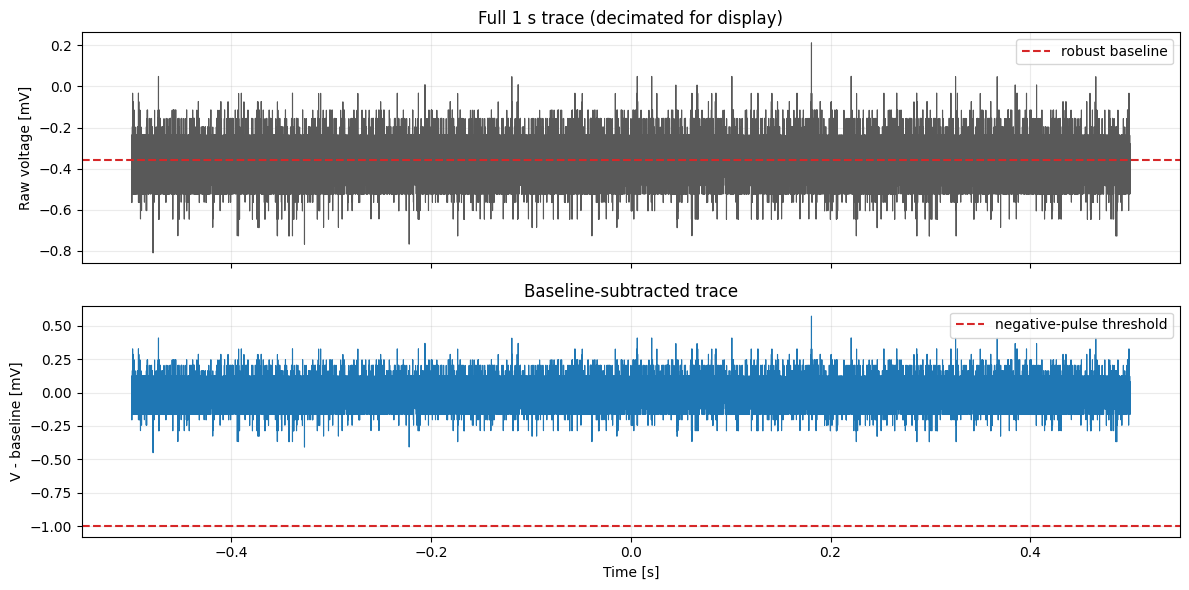

In [5]:
fastplot = True
decim = max(1, len(time_ns) // 50000) # show evert N-th sample of the waveform, not every recorded point

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
if fastplot: 
    axes[0].plot(trace_s[::decim], trace_mV[::decim], lw=0.8, color="0.35")
else:
    axes[0].plot(trace_s, trace_mV, lw=0.8, color="0.35")
axes[0].axhline(baseline_mV, color="tab:red", ls="--", label="robust baseline")
axes[0].set_ylabel("Raw voltage [mV]")
if fastplot:
    axes[0].set_title("Full 1 s trace (decimated for display)")
else:
    axes[0].set_title("Full 1 s trace")
axes[0].legend()


if fastplot: 
    axes[1].plot(trace_s[::decim], trace_bs_mV[::decim], lw=0.8, color="tab:blue")
else:
    axes[1].plot(trace_s, trace_bs_mV, lw=0.8, color="tab:blue")
axes[1].axhline(-config_dict['event_threshold_mV'], color="tab:red", ls="--", label="negative-pulse threshold")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("V - baseline [mV]")
axes[1].set_title("Baseline-subtracted trace")
axes[1].legend()
fig.tight_layout()


## Pulse Finding (one-file example)

In [6]:
sample_pulses = measure_pulses(time_ns, trace_bs_mV, sample_dt_ns, config_dict)
print(f"File 1 pulses above {config_dict['event_threshold_mV']:.2f} mV: {len(sample_pulses)}")
if sample_pulses:
    print("First few pulse times [s]:", [round(row["peak_time_s"], 6) for row in sample_pulses[:10]])
print(sample_pulses[0].keys())

File 1 pulses above 1.00 mV: 124
First few pulse times [s]: [0.005214, 0.015894, 0.029917, 0.059632, 0.069699, 0.072746, 0.077075, 0.098268, 0.109537, 0.110606]
dict_keys(['start_index', 'stop_index', 'peak_index', 'peak_time_ns', 'peak_time_s', 'peak_amplitude_mV', 'charge_mV_ns', 'width50_ns', 'rise_time_ns', 'positive_overshoot_mV'])


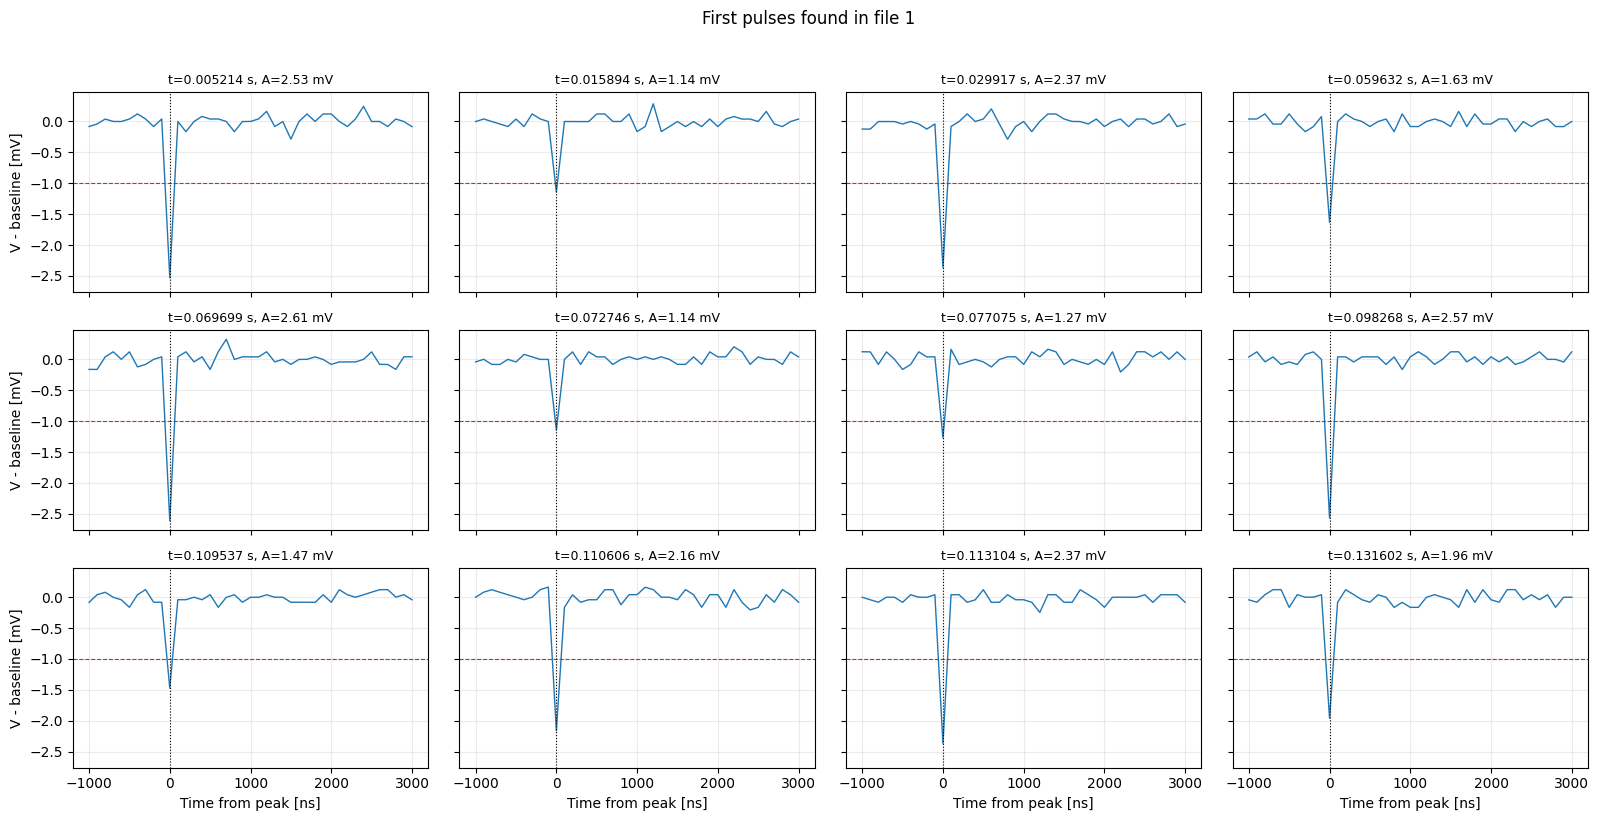

In [7]:
zoom_n = min(12, len(sample_pulses))
if zoom_n == 0:
    print("No pulses found in file 1 at this threshold.")
else:
    fig, axes = plt.subplots(3, 4, figsize=(16, 8), sharex=True, sharey=True)
    axes = axes.ravel()
    pre = int(round(config_dict['pre_event_ns'] / sample_dt_ns))
    post = int(round(config_dict['post_event_ns'] / sample_dt_ns))
    for ax, pulse in zip(axes, sample_pulses[:zoom_n]):
        idx = pulse["peak_index"]
        lo = max(0, idx - pre)
        hi = min(len(time_ns), idx + post + 1)
        local_t_ns = time_ns[lo:hi] - time_ns[idx]
        ax.plot(local_t_ns, trace_bs_mV[lo:hi], color="tab:blue", lw=1)
        ax.axhline(-config_dict['event_threshold_mV'], color="tab:red", ls="--", lw=0.8)
        ax.axvline(0, color="black", ls=":", lw=0.8)
        ax.set_title(f"t={pulse['peak_time_s']:.6f} s, A={pulse['peak_amplitude_mV']:.2f} mV", fontsize=9)
    for ax in axes[zoom_n:]:
        ax.set_axis_off()
    for ax in axes[-4:]:
        ax.set_xlabel("Time from peak [ns]")
    for ax in axes[::4]:
        ax.set_ylabel("V - baseline [mV]")
    fig.suptitle("First pulses found in file 1", y=1.02)
    fig.tight_layout()

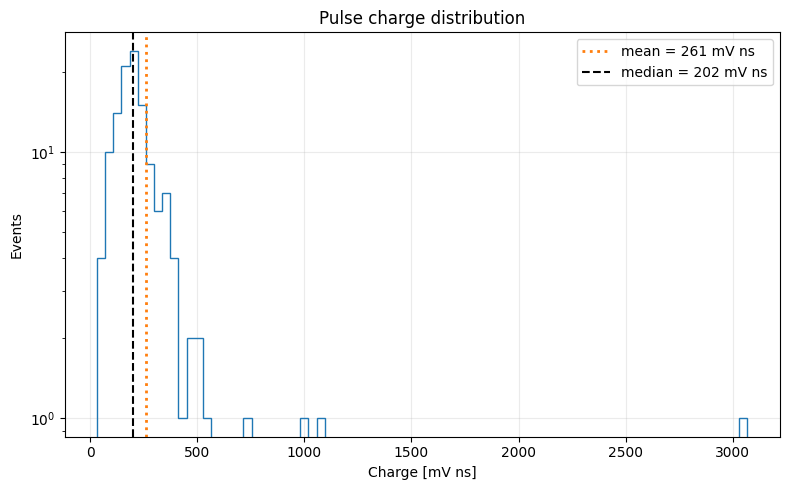

In [8]:
charges = np.array([p["charge_mV_ns"] for p in sample_pulses])
charges = charges[np.isfinite(charges)]

mean_charge = np.mean(charges)
median_charge = np.median(charges)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(charges, bins=80, histtype="step", color="tab:blue")
ax.axvline(mean_charge, color="tab:orange", ls=":", lw=2, label=f"mean = {mean_charge:.3g} mV ns")
ax.axvline(median_charge, color="black", ls="--", lw=1.5, label=f"median = {median_charge:.3g} mV ns")

ax.set_xlabel("Charge [mV ns]")
ax.set_ylabel("Events")
ax.set_title("Pulse charge distribution")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()

# All files

In [9]:
events, file_summary = process_all_files(FILES, sample_dt_ns, config_dict)

In [10]:

# print(f"Processed {len(FILES)} files")
print(f"Total events: {len(events['peak_index'])}")
print(f"Total live time: {np.sum(file_summary['duration_s'])} s")
print(f"Overall rate: {np.sum( file_summary['n_events'] ) / np.sum( file_summary['duration_s'] ):.3f} Hz")
print(f'file_summary: {file_summary.keys()}')
print(f'events: {events.keys()}')


Total events: 1303
Total live time: 10.0 s
Overall rate: 130.300 Hz
file_summary: dict_keys(['file', 'file_index', 'duration_s', 'n_events', 'rate_hz', 'baseline_mV', 'noise_mV', 'layout'])
events: dict_keys(['start_index', 'stop_index', 'peak_index', 'peak_time_ns', 'peak_time_s', 'peak_amplitude_mV', 'charge_mV_ns', 'width50_ns', 'rise_time_ns', 'positive_overshoot_mV', 'file', 'file_index', 'baseline_mV', 'noise_mV'])


### per file

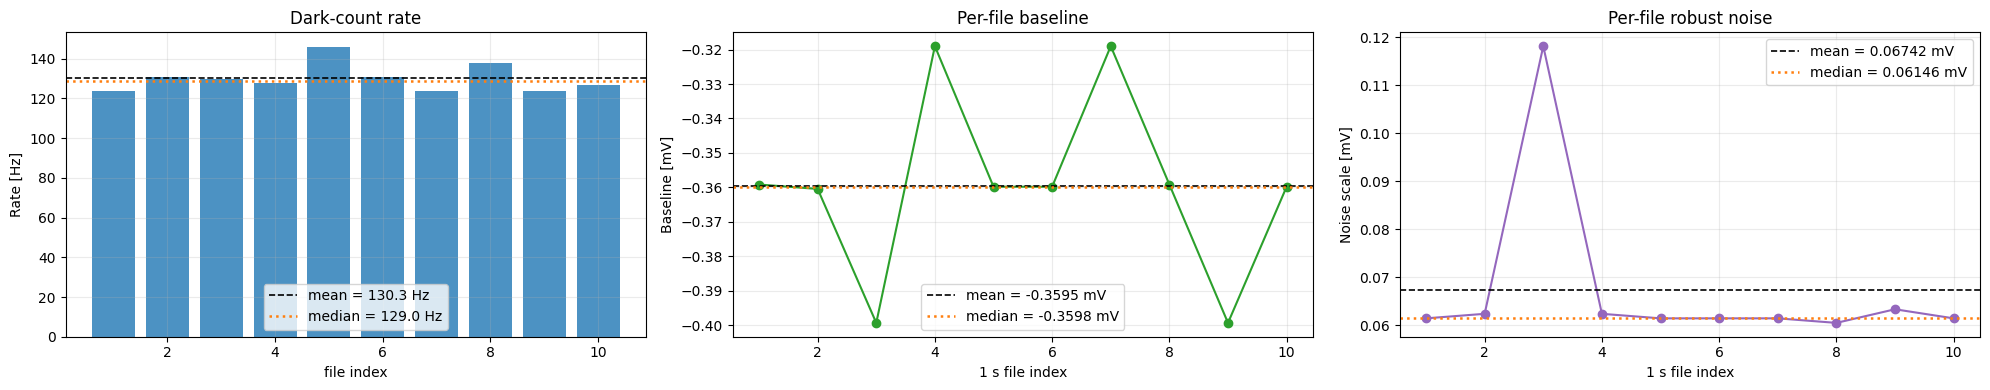

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
rate_mean, rate_median = get_mean_median(file_summary["rate_hz"])
axes[0].bar(file_summary["file_index"] + 1, file_summary["rate_hz"], color="tab:blue", alpha=0.8)
axes[0].axhline(rate_mean, color="black", ls="--", lw=1.2, label=f"mean = {rate_mean:.1f} Hz")
axes[0].axhline(rate_median, color="tab:orange", ls=":", lw=1.8, label=f"median = {rate_median:.1f} Hz")
axes[0].set_xlabel("file index")
axes[0].set_ylabel("Rate [Hz]")
axes[0].set_title("Dark-count rate")
axes[0].legend(loc="lower center")

baseline_mean, baseline_median = get_mean_median(file_summary["baseline_mV"])
axes[1].plot(file_summary["file_index"] + 1, file_summary["baseline_mV"], marker="o", color="tab:green")
axes[1].axhline(baseline_mean, color="black", ls="--", lw=1.2, label=f"mean = {baseline_mean:.4g} mV")
axes[1].axhline(baseline_median, color="tab:orange", ls=":", lw=1.8, label=f"median = {baseline_median:.4g} mV")
axes[1].set_xlabel("1 s file index")
axes[1].set_ylabel("Baseline [mV]")
axes[1].set_title("Per-file baseline")
axes[1].legend(loc="lower center")

noise_mean, noise_median = get_mean_median(file_summary["noise_mV"])
axes[2].plot(file_summary["file_index"] + 1, file_summary["noise_mV"], marker="o", color="tab:purple")
axes[2].axhline(noise_mean, color="black", ls="--", lw=1.2, label=f"mean = {noise_mean:.4g} mV")
axes[2].axhline(noise_median, color="tab:orange", ls=":", lw=1.8, label=f"median = {noise_median:.4g} mV")
axes[2].set_xlabel("1 s file index")
axes[2].set_ylabel("Noise scale [mV]")
axes[2].set_title("Per-file robust noise")
axes[2].legend(loc="best")
fig.tight_layout()

### all events

In [12]:
feature_names = [
    "peak_amplitude_mV",
    "charge_mV_ns",
    "width50_ns",
    "rise_time_ns",
    "positive_overshoot_mV",
]

if not events:
    print("No events found. Lower EVENT_THRESHOLD_MV and rerun from Pulse finding.")
else:
    print("Event-feature summary")
    print("quantity                    mean       median        std        q05        q95")
    for name in feature_names:
        values = events[name]
        values = values[np.isfinite(values)]
        q05, q95 = np.quantile(values, [0.05, 0.95])
        print(f"{name:24s} {np.mean(values):10.4g} {np.median(values):10.4g} {np.std(values, ddof=1):10.4g} {q05:10.4g} {q95:10.4g}")


Event-feature summary
quantity                    mean       median        std        q05        q95
peak_amplitude_mV             2.325      1.918      1.827      1.061      4.407
charge_mV_ns                  240.7      207.2      211.2      72.19      460.2
width50_ns                    100.4        100      6.118      94.58      107.1
rise_time_ns                  81.27         80      11.47      73.63      86.76
positive_overshoot_mV        0.1666     0.1633    0.05431    0.08291     0.2462


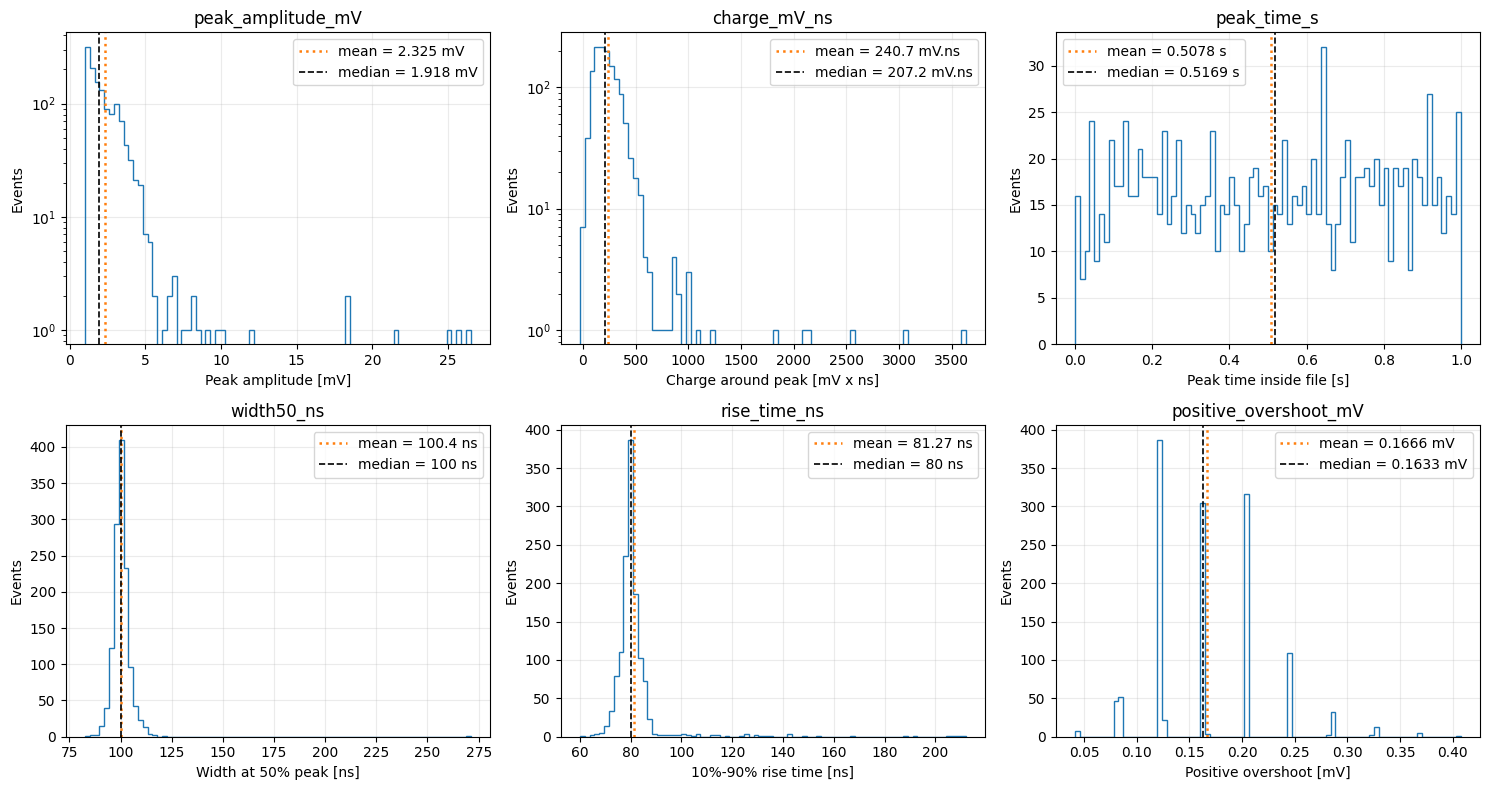

In [13]:
if events:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    plot_specs = [
        ("peak_amplitude_mV", "Peak amplitude [mV]", "mV", True),
        ("charge_mV_ns", "Charge around peak [mV x ns]", "mV.ns", True),
        ("peak_time_s", "Peak time inside file [s]", "s", False),
        ("width50_ns", "Width at 50% peak [ns]", "ns", False),
        ("rise_time_ns", f"{config_dict['rise_low_fracion']:.0%}-{config_dict['rise_high_fracion']:.0%} rise time [ns]", "ns", False),
        ("positive_overshoot_mV", "Positive overshoot [mV]", "mV", False),
    ]
    for ax, (name, xlabel, unit, log_y) in zip(axes, plot_specs):
        values = events[name]
        values = values[np.isfinite(values)]
        mean, median = get_mean_median(values)
        ax.hist(values, bins=80, histtype="step", color="tab:blue")
        ax.axvline(mean, color="tab:orange", ls=":", lw=1.8, label=f"mean = {mean:.4g} {unit}")
        ax.axvline(median, color="black", ls="--", lw=1.2, label=f"median = {median:.4g} {unit}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Events")
        ax.set_title(name)
        if log_y:
            ax.set_yscale("log")
        ax.legend(loc="best")
    fig.tight_layout()


# Sanity checks

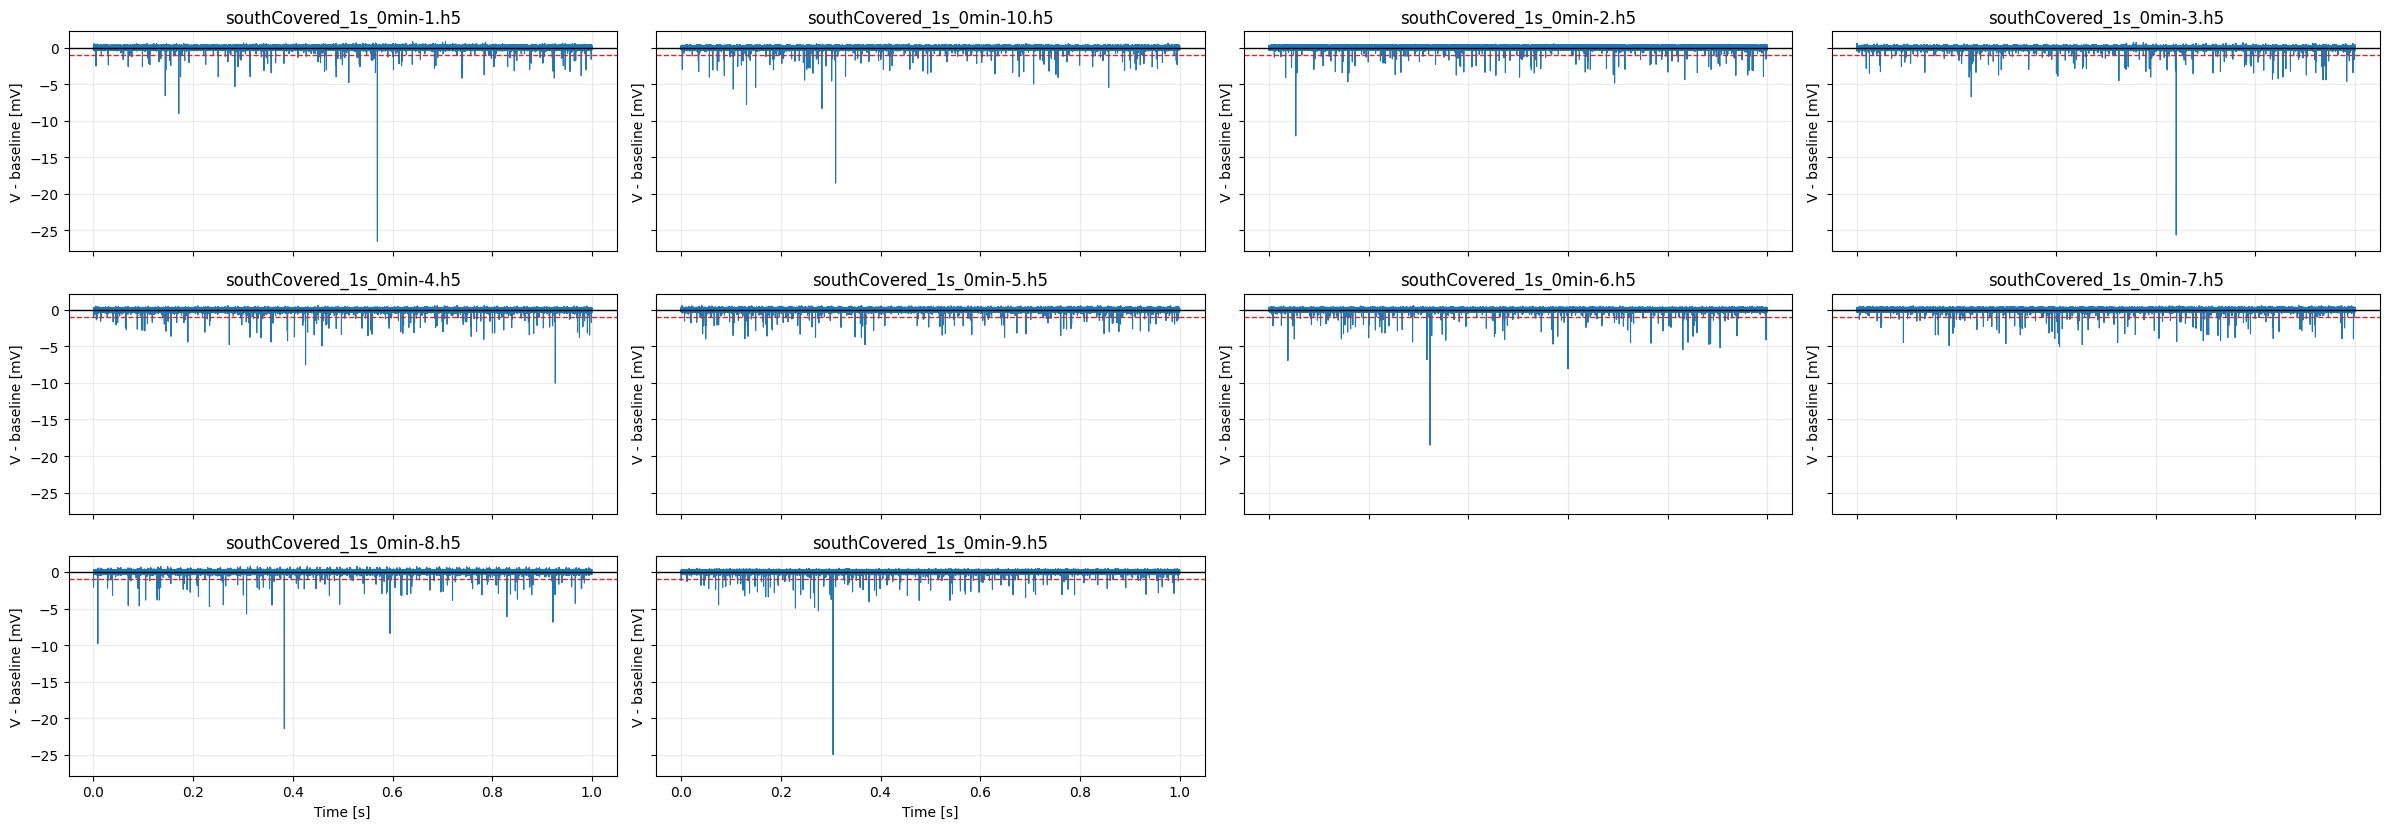

In [14]:
fastplot = False
time_s = (time_ns - time_ns[0]) * 1e-9
decim = max(1, len(time_s) // 50_000)


ncols = 4  # choose this
nfiles = len(FILES)
nrows = int(np.ceil(nfiles / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(6 * ncols, 2.8 * nrows),
    sharex=True,
    sharey=True,
)

axes = np.atleast_1d(axes).ravel()

for ax, file in zip(axes, FILES):
    time_ns, voltage_mV, metadata, adc_step_mV = read_continuous_trace(file)
    voltage_bs_mV, baseline_mV, noise_mV = baseline_subtract_trace(voltage_mV)

    if fastplot:
        ax.plot(time_s[::decim], voltage_bs_mV[::decim], lw=0.8)
    else:
        ax.plot(time_s, voltage_bs_mV, lw=0.8)
    ax.axhline(0, color="black", lw=1)
    ax.axhline(-config_dict['event_threshold_mV'], color="tab:red", ls="--", lw=1)
    ax.set_title(file.name)
    ax.set_ylabel("V - baseline [mV]")

for ax in axes[len(FILES):]:
    ax.set_axis_off()

for ax in axes[-ncols:]:
    ax.set_xlabel("Time [s]")

fig.tight_layout()

In [15]:
# plot_specs : list[tuple]
#         Tuples of (name, xlabel, unit, log_y, hist_range).

plot_specs = [
    ("peak_amplitude_mV", "Peak amplitude [mV]", "mV", True, None),
    ("charge_mV_ns", "Charge around peak [mV x ns]", "mV.ns", True, None),
    ("peak_time_s", "Peak time inside file [s]", "s", False, None),
    ("width50_ns", "Width at 50% peak [ns]", "ns", False, (75, 125)),
    ("rise_time_ns",
     f"{config_dict['rise_low_fracion']:.0%}-{config_dict['rise_high_fracion']:.0%} rise time [ns]",  "ns", False, None ),
    ("positive_overshoot_mV", "Positive overshoot [mV]", "mV", False, None),
]

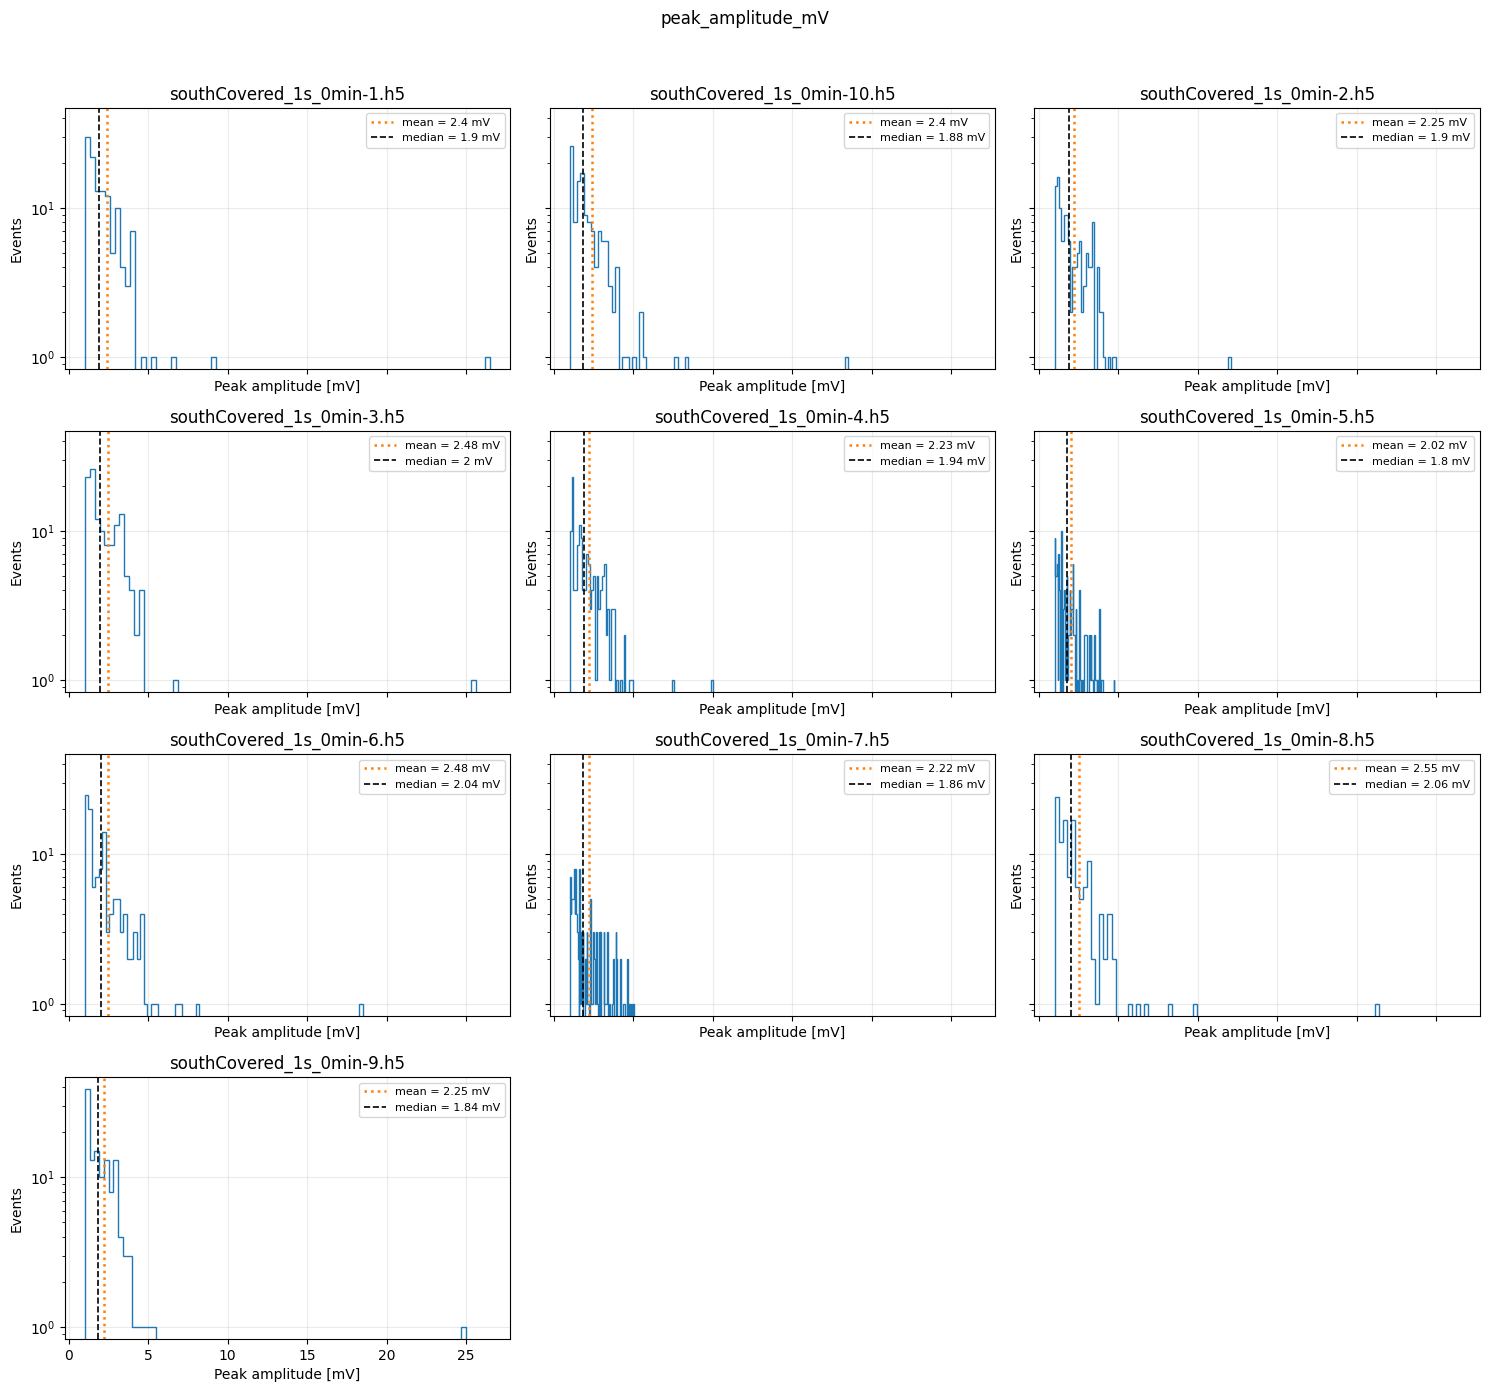

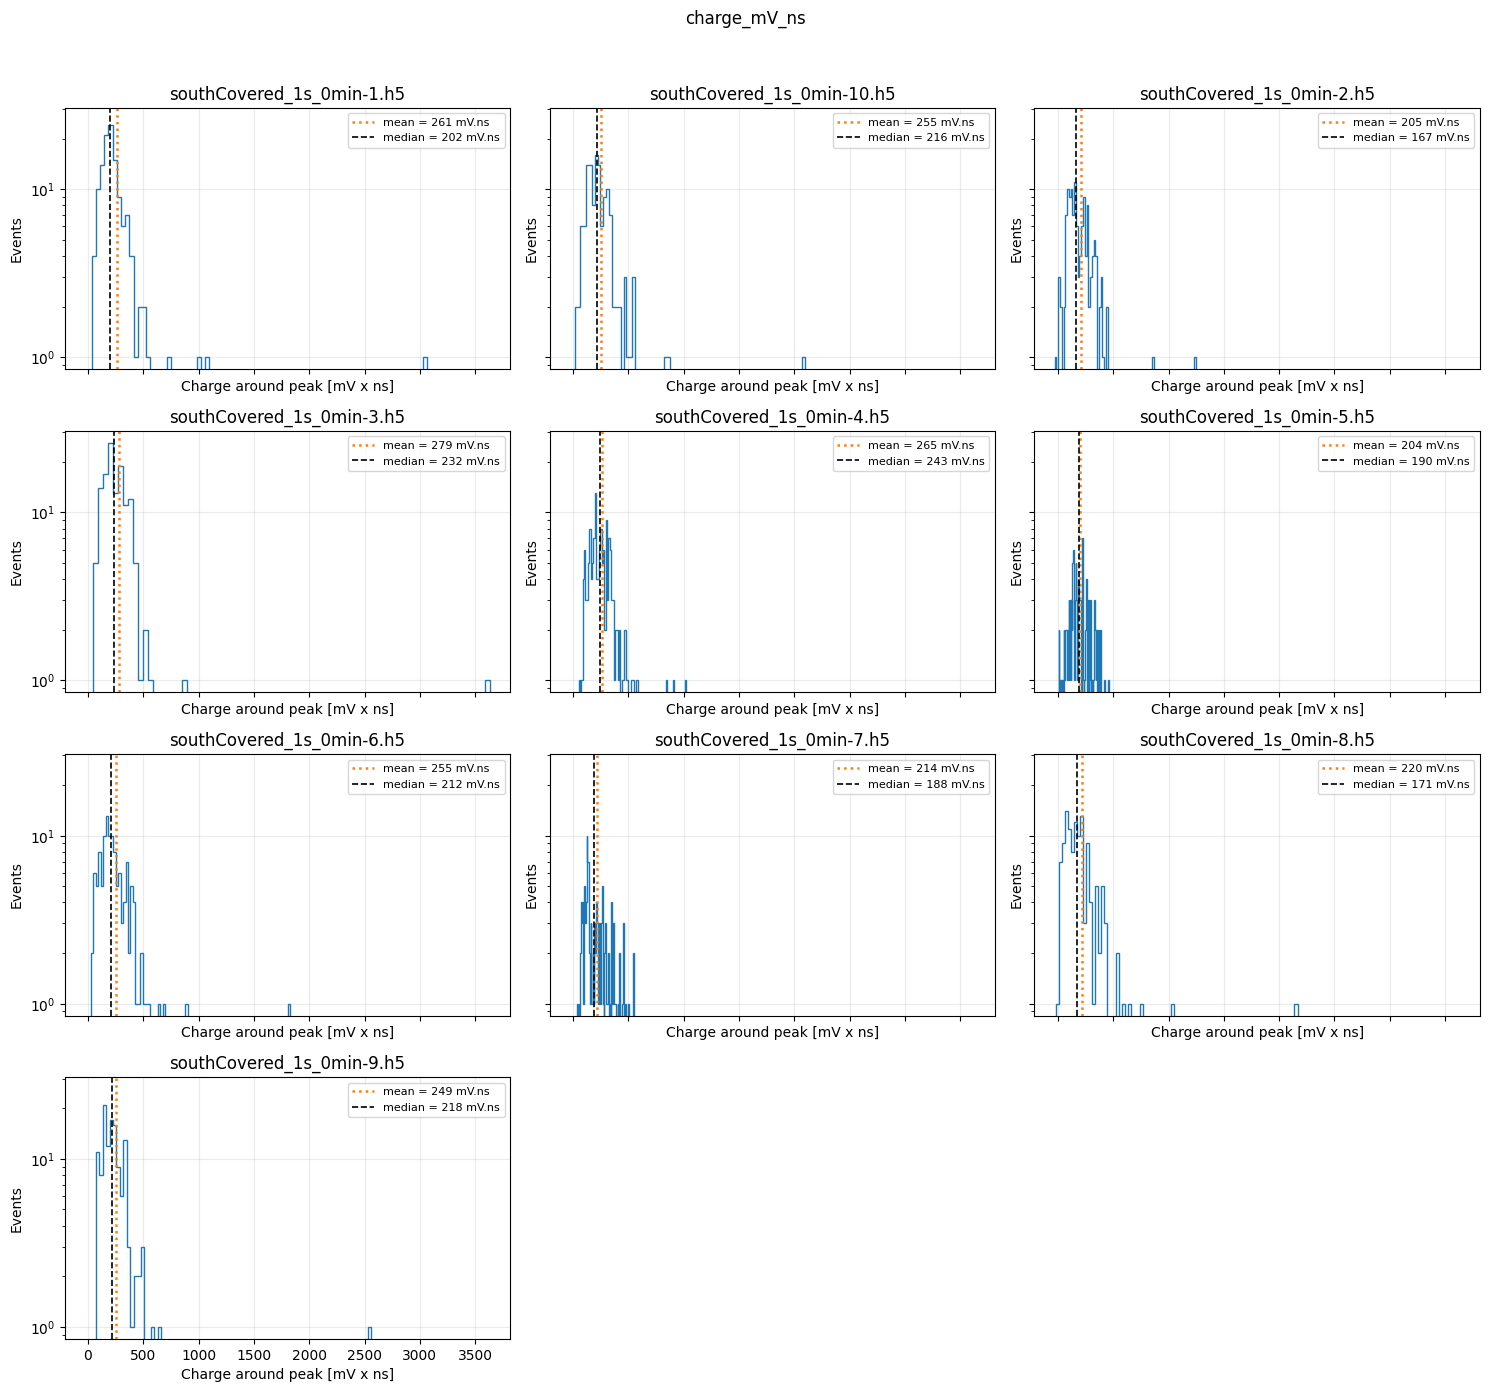

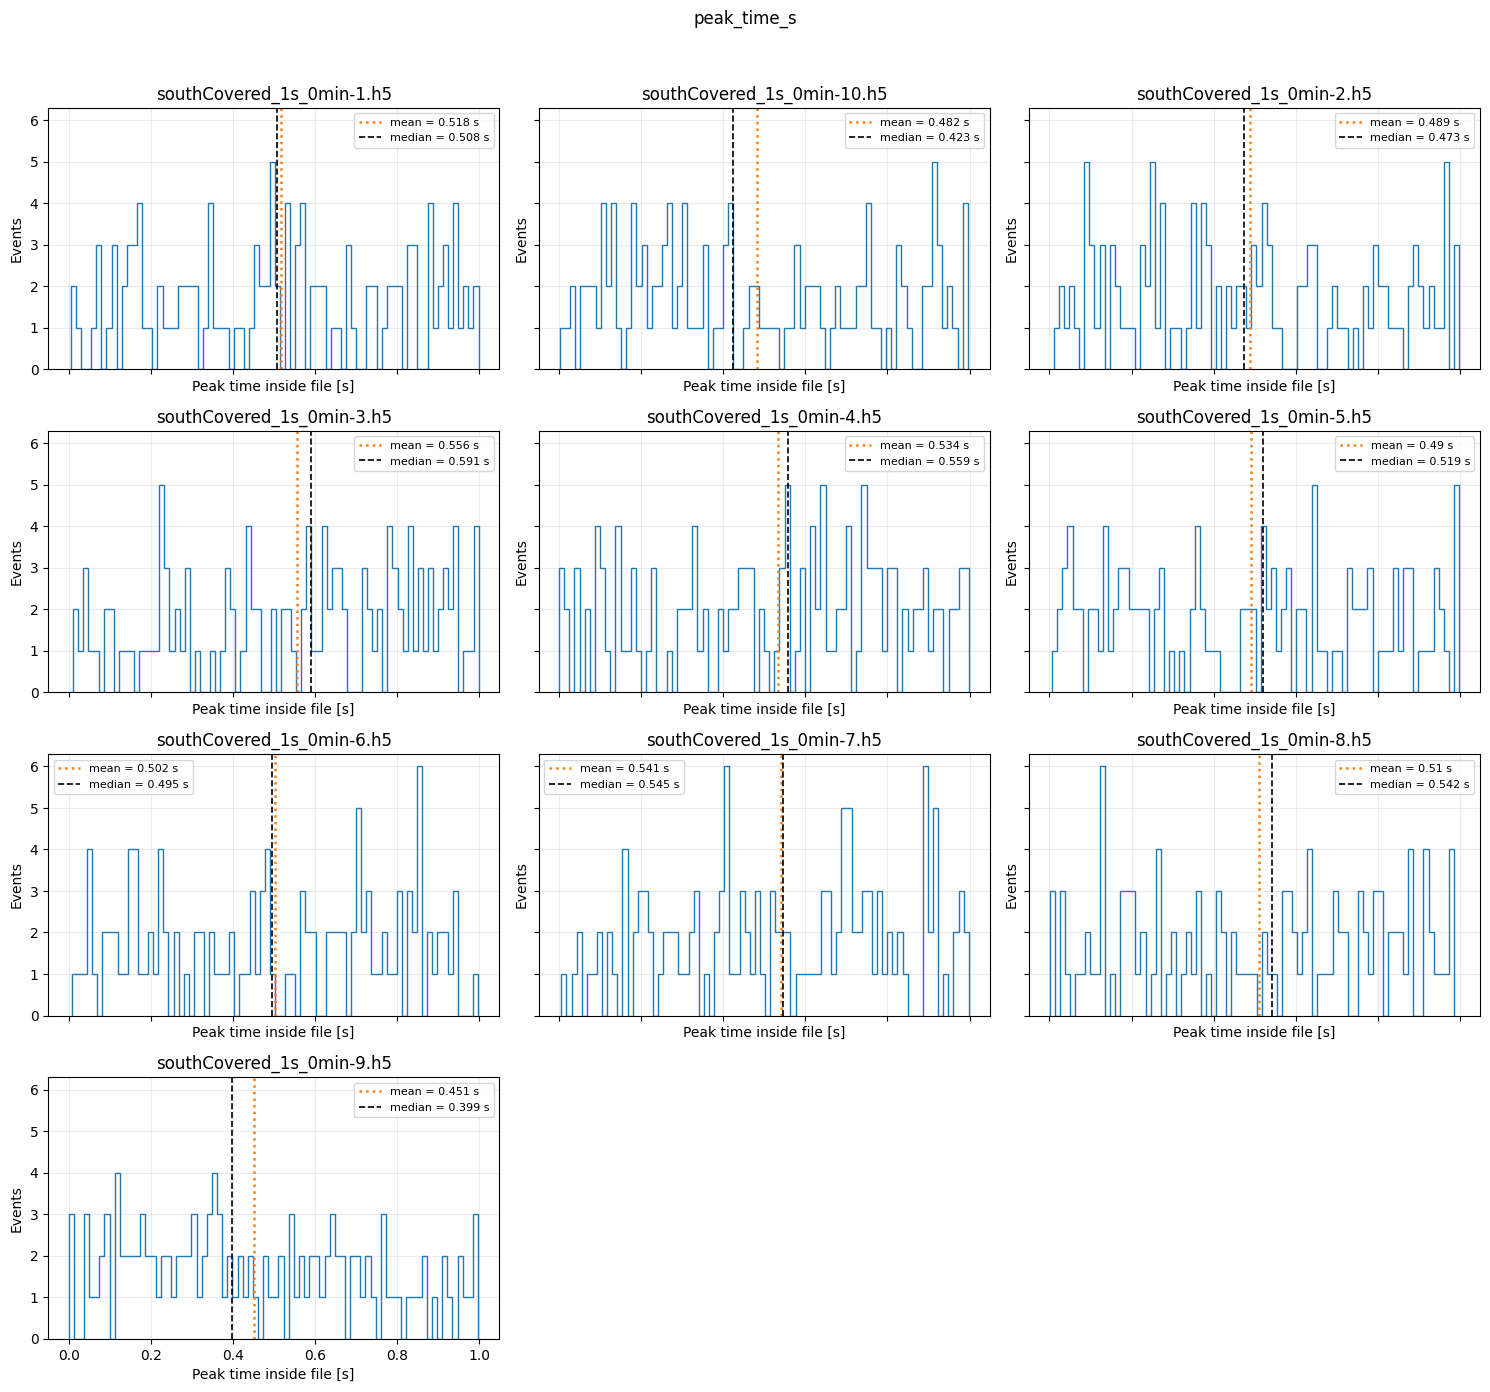

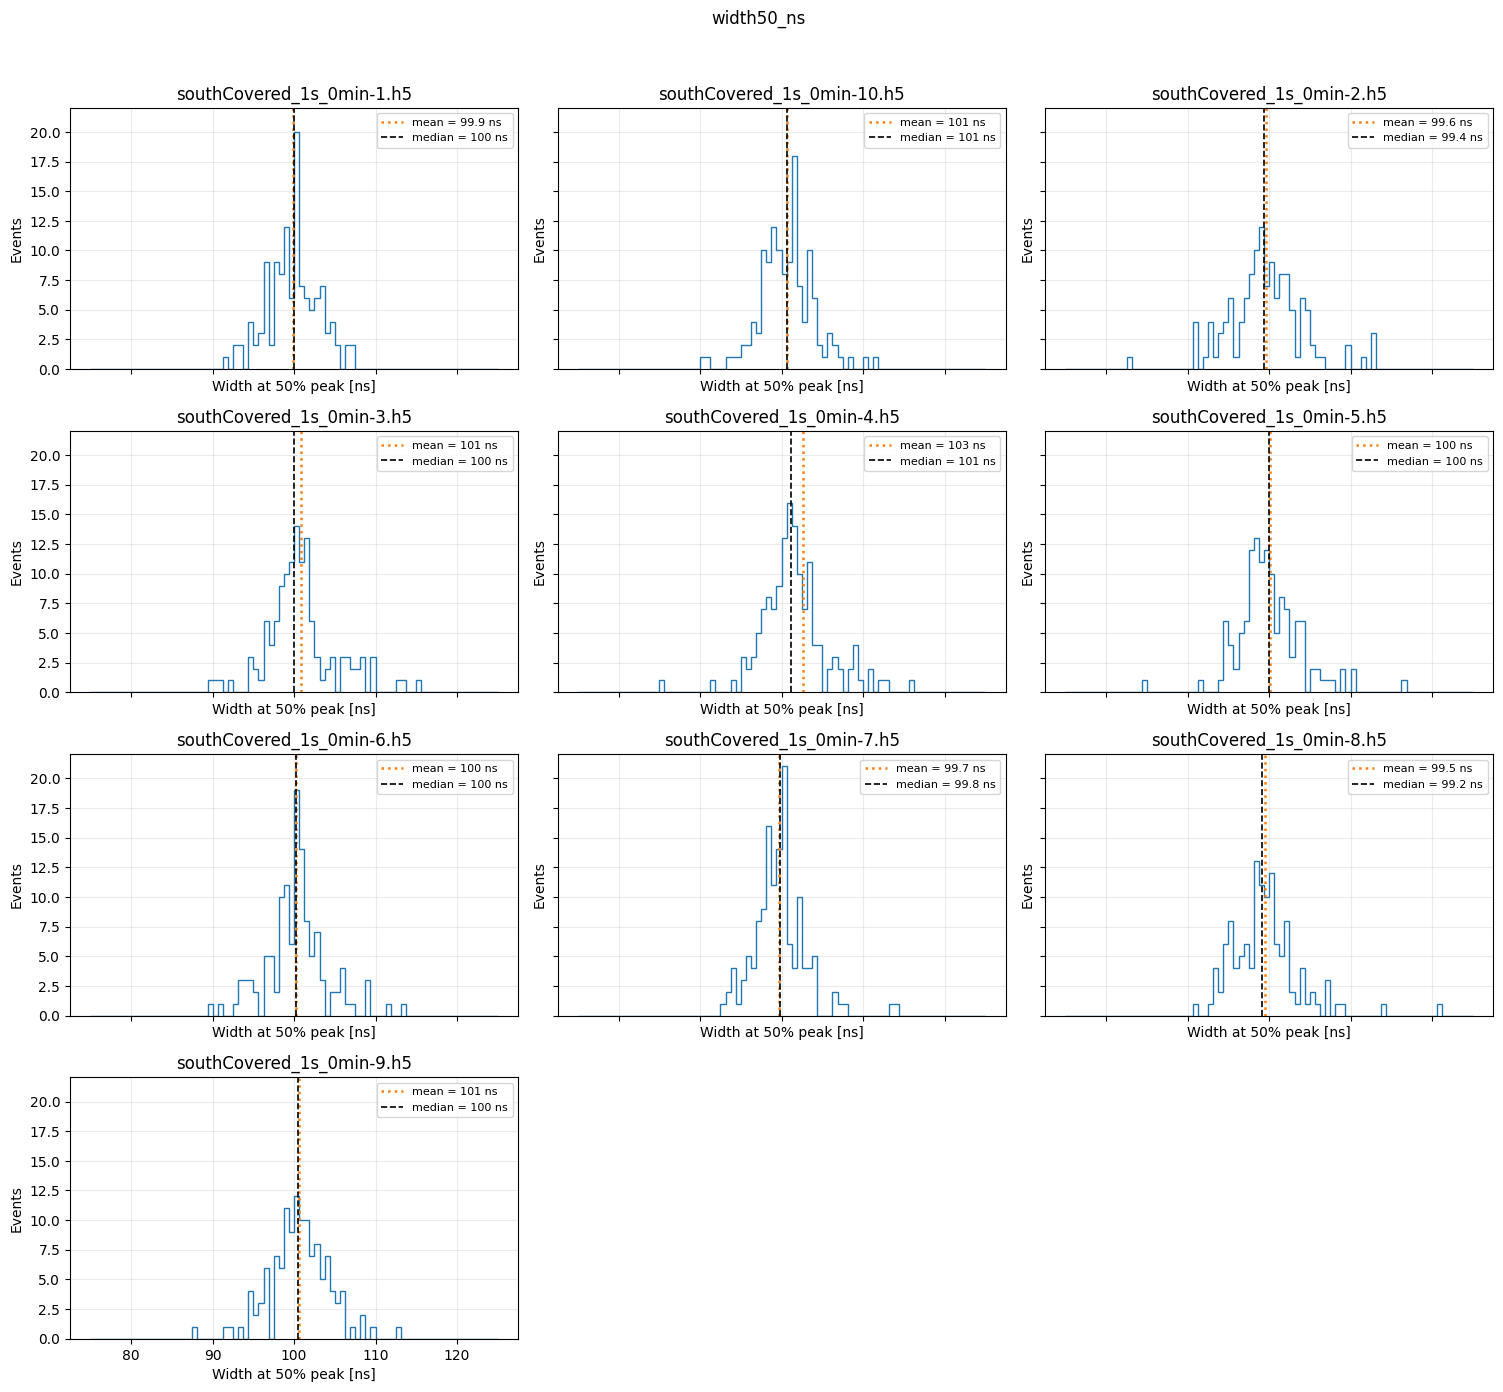

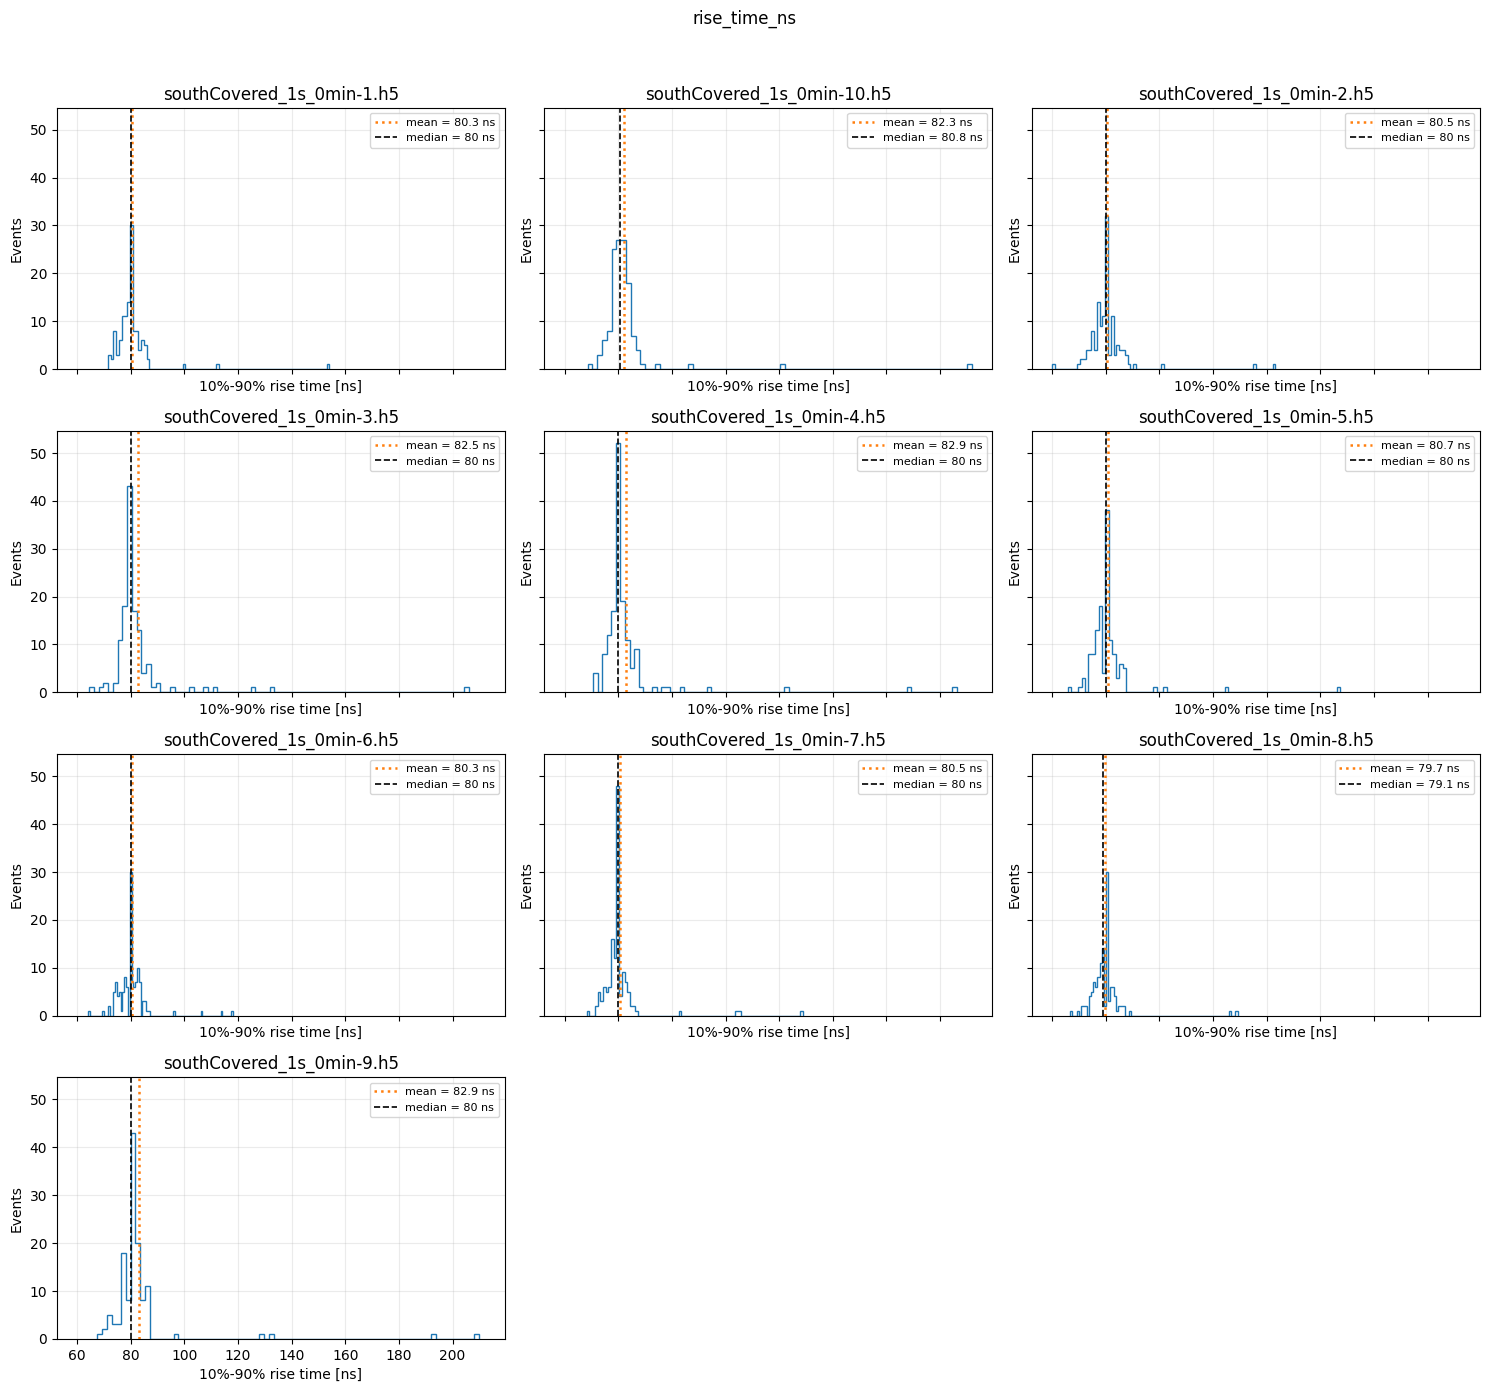

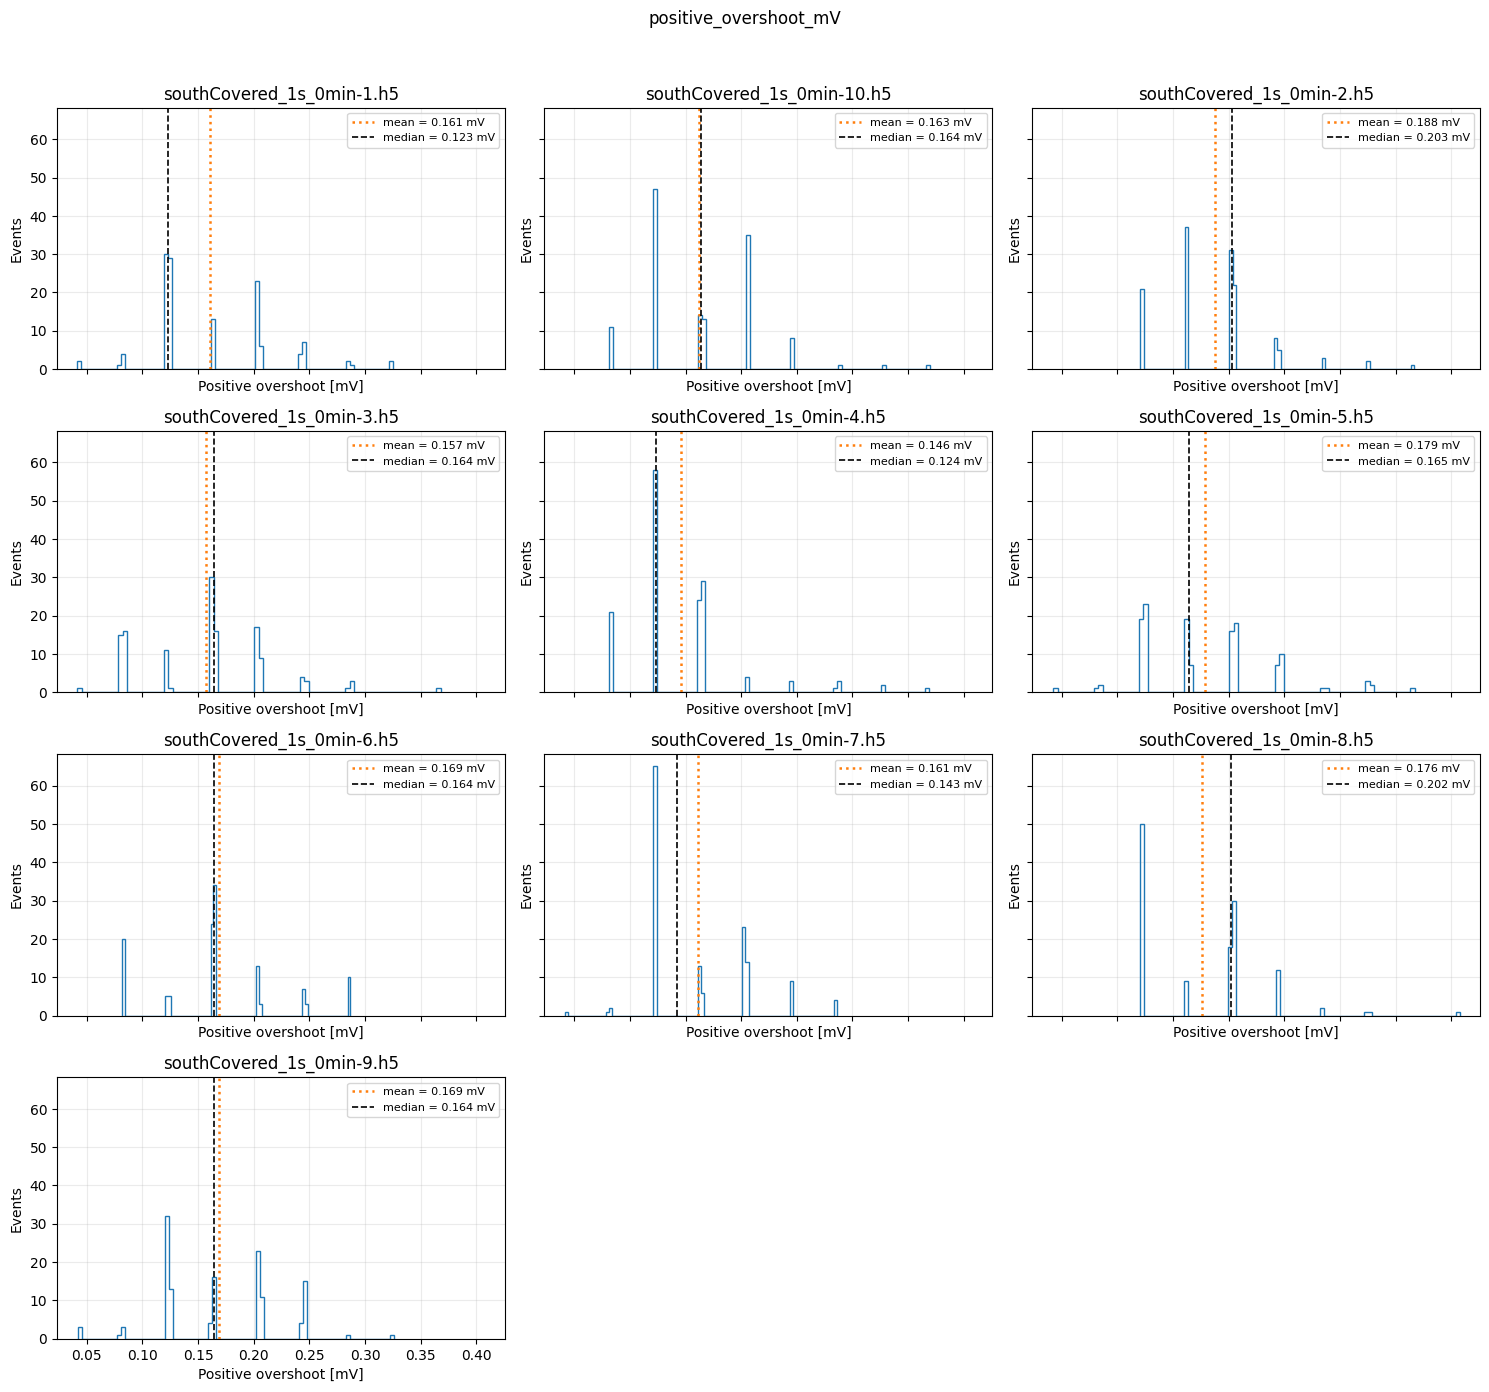

In [16]:
plot_event_variables_per_file(events, FILES, plot_specs, ncols=3, same_plot=False)

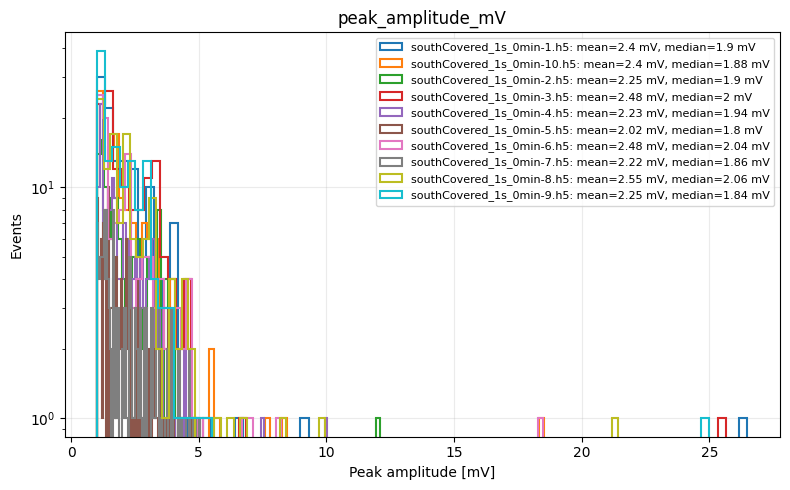

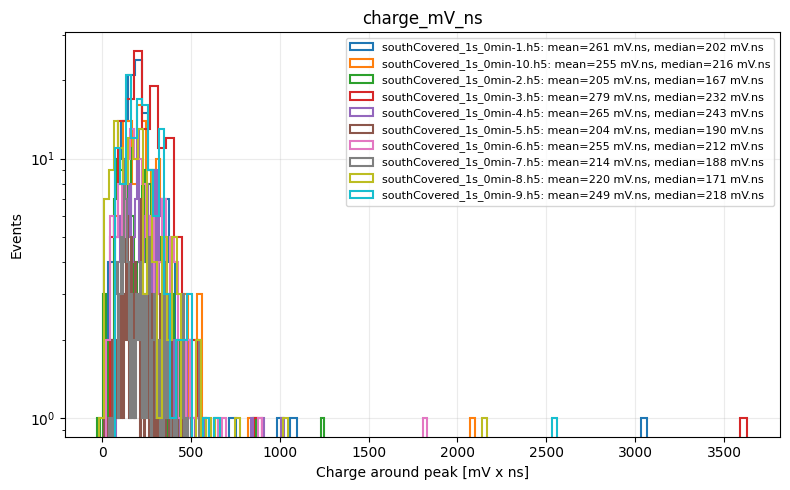

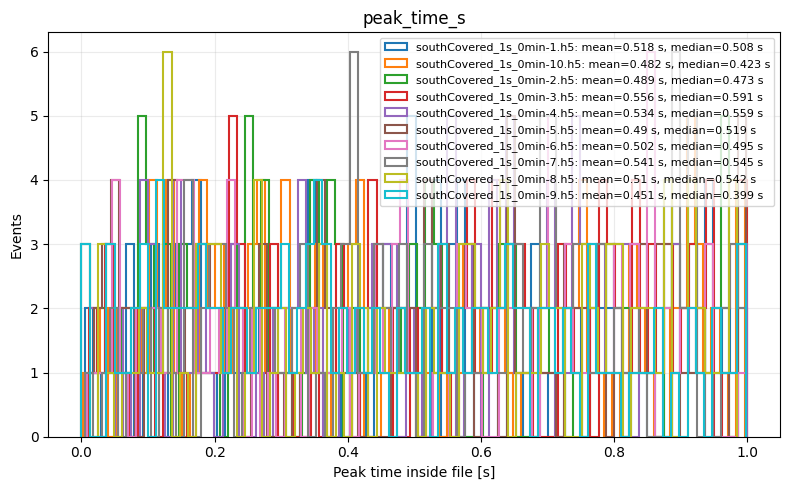

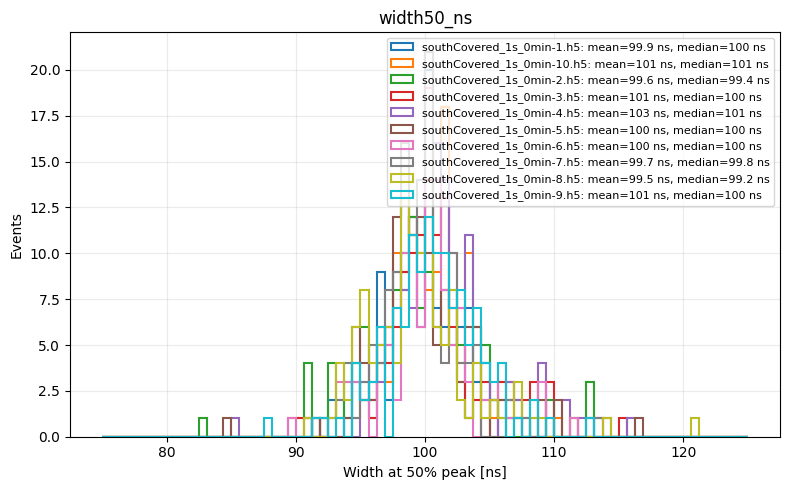

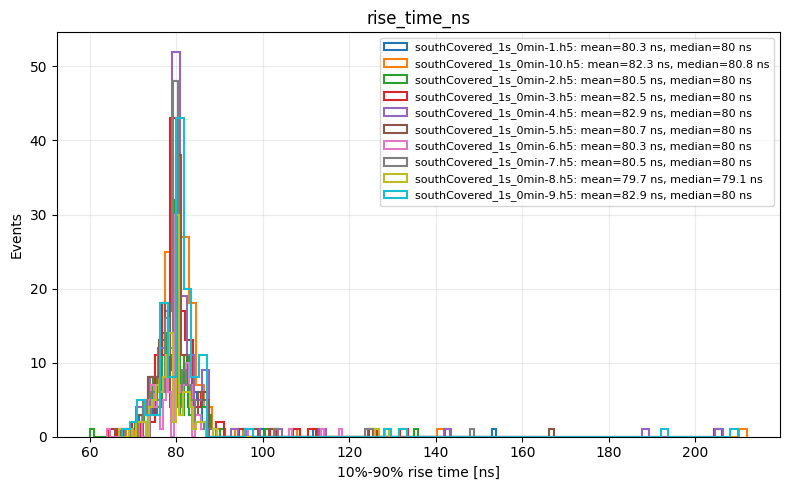

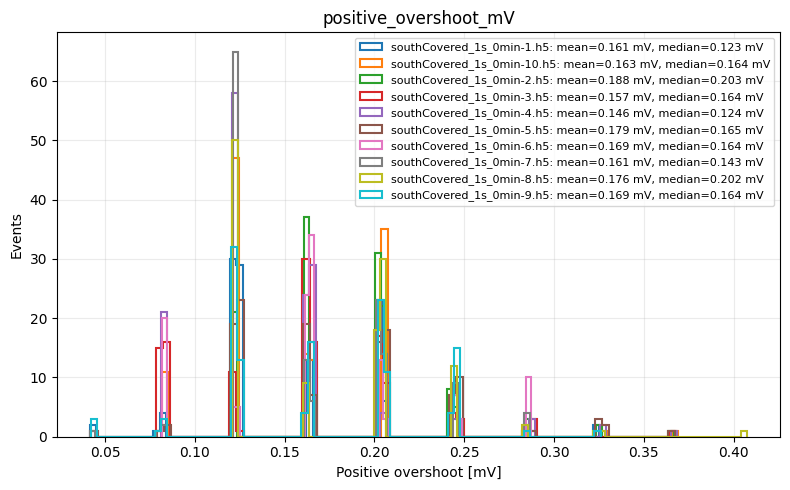

In [17]:
plot_event_variables_per_file(events, FILES, plot_specs, same_plot=True)